# Statistical Modelling using Python - Music data

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

## Data Collection:

In [2]:
music_data = pd.read_csv(r"D:\Study\Projects\Statistical Modelling using Python\data\musicdata.csv")

In [3]:
music_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 22 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Unnamed: 0        100 non-null    int64  
 1   Track Name        94 non-null     object 
 2   Artists           94 non-null     object 
 3   Album Name        94 non-null     object 
 4   Album ID          100 non-null    object 
 5   Track ID          100 non-null    object 
 6   Popularity        100 non-null    int64  
 7   Release Date      100 non-null    object 
 8   Duration (ms)     100 non-null    int64  
 9   Explicit          100 non-null    bool   
 10  External URLs     100 non-null    object 
 11  Danceability      100 non-null    float64
 12  Energy            100 non-null    float64
 13  Key               100 non-null    int64  
 14  Loudness          100 non-null    float64
 15  Mode              100 non-null    int64  
 16  Speechiness       100 non-null    float64
 17

In [4]:
music_data.describe()

,Unnamed: 0,Popularity,Duration (ms),Danceability,Energy,Key,Loudness,Mode,Speechiness,Acousticness,Instrumentalness,Liveness,Valence,Tempo
count,100.000000,100.000000,100.000000,100.000000,100.00000,100.00000,100.000000,100.00000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000
mean,49.500000,50.950000,210543.180000,0.767210,0.79763,4.54000,-4.399930,0.43000,0.115615,0.165559,0.005236,0.185791,0.659259,119.371470
std,29.011492,16.496326,37961.050214,0.085302,0.11572,3.64434,1.612703,0.49757,0.075819,0.152536,0.028979,0.170086,0.183901,29.058698
min,0.000000,0.000000,141862.000000,0.501000,0.47700,0.00000,-8.272000,0.00000,0.029400,0.001090,0.000000,0.034600,0.073900,78.991000
25%,24.750000,46.000000,186098.500000,0.714750,0.71125,1.00000,-5.465250,0.00000,0.057700,0.037500,0.000000,0.076900,0.558250,97.042500
50%,49.500000,56.500000,205076.000000,0.772000,0.81700,4.00000,-4.252500,0.00000,0.086150,0.128000,0.000000,0.122000,0.672500,107.984000
75%,74.250000,62.000000,226079.000000,0.826500,0.88125,7.25000,-3.163250,1.00000,0.160000,0.236750,0.000041,0.225250,0.793750,132.259000
max,99.000000,72.000000,367818.000000,0.959000,0.98800,11.00000,-0.223000,1.00000,0.340000,0.620000,0.270000,0.823000,0.940000,189.857000


In [5]:
music_data.head()

,Unnamed: 0,Track Name,Artists,Album Name,Album ID,Track ID,Popularity,Release Date,Duration (ms),Explicit,...,Energy,Key,Loudness,Mode,Speechiness,Acousticness,Instrumentalness,Liveness,Valence,Tempo
0,0,Bijlee Bijlee,Harrdy Sandhu,Bijlee Bijlee,3tG0IGB24sRhGFLs5F1Km8,1iZLpuGMr4tn1F5bZu32Kb,70,2021-10-30,168450,False,...,0.670,1,-5.313,0,0.1430,0.2690,0.000000,0.0733,0.643,100.004
1,1,Expert Jatt,Nawab,Expert Jatt,2gibg5SCTep0wsIMefGzkd,7rr6n1NFIcQXCsi43P0YNl,65,2018-01-18,199535,False,...,0.948,6,-2.816,0,0.1990,0.2980,0.000000,0.0784,0.647,172.038
2,2,"Kaun Nachdi (From ""Sonu Ke Titu Ki Sweety"")","Guru Randhawa, Neeti Mohan",High Rated Gabru - Guru Randhawa,6EDbwGsQNQRLf73c7QwZ2f,3s7m0jmCXGcM8tmlvjCvAa,64,2019-03-02,183373,False,...,0.830,4,-3.981,0,0.0455,0.0357,0.000000,0.0419,0.753,127.999
3,3,Na Na Na Na,J Star,Na Na Na Na,4xBqgoiRSOMU1VlKuntVQW,5GjxbFTZAMhrVfVrNrrwrG,52,2015,209730,False,...,0.863,3,-3.760,1,0.0413,0.3760,0.000014,0.0916,0.807,95.000
4,4,Patiala Peg,Diljit Dosanjh,Do Gabru - Diljit Dosanjh & Akhil,1uxDllRe9CPhdr8rhz2QCZ,6TikcWOLRsPq66GBx2jk67,46,2018-07-10,188314,False,...,0.811,5,-3.253,0,0.1840,0.0259,0.000000,0.3110,0.835,175.910


## Data Cleaning:

In [6]:
music_data.isnull().sum()

Unnamed: 0          0
Track Name          6
Artists             6
Album Name          6
Album ID            0
Track ID            0
Popularity          0
Release Date        0
Duration (ms)       0
Explicit            0
External URLs       0
Danceability        0
Energy              0
Key                 0
Loudness            0
Mode                0
Speechiness         0
Acousticness        0
Instrumentalness    0
Liveness            0
Valence             0
Tempo               0
dtype: int64

In [7]:
music_data_cleaned = music_data.drop(columns=['Unnamed: 0'])

In [8]:
col_missed_values = ['Track Name', 'Artists', 'Album Name']
music_data_cleaned[col_missed_values] = music_data_cleaned[col_missed_values].fillna('Unknown')

## Data Distribution:

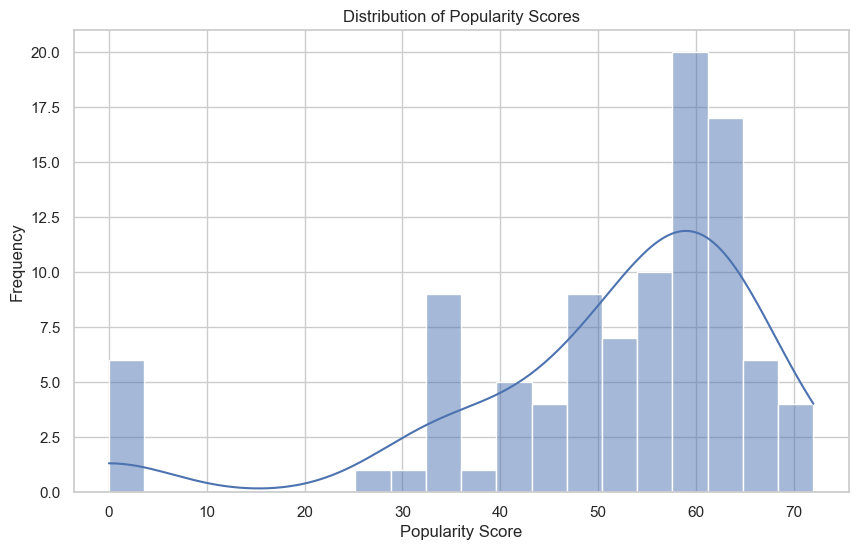

In [9]:
sns.set(style="whitegrid")

# plotting the distribution of popularity
plt.figure(figsize=(10, 6))
sns.histplot(music_data_cleaned['Popularity'], bins=20, kde=True)
plt.title('Distribution of Popularity Scores')
plt.xlabel('Popularity Score')
plt.ylabel('Frequency')
plt.show()

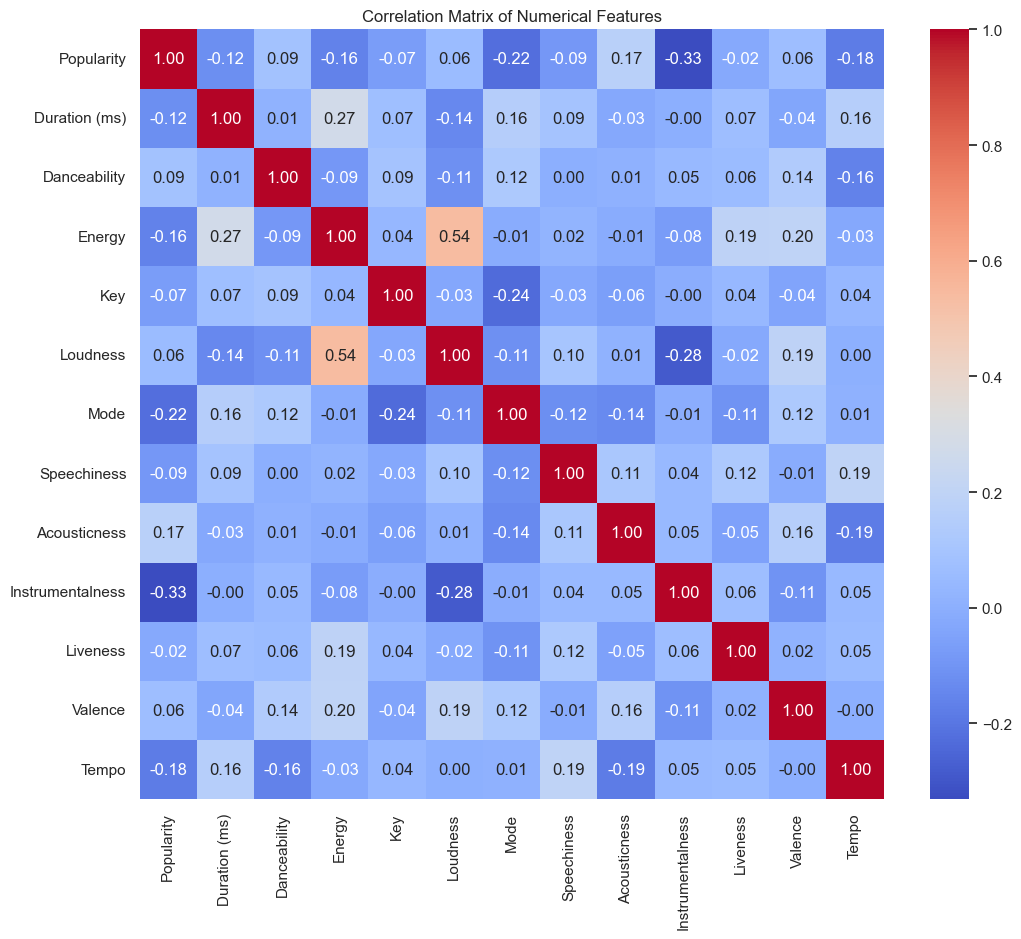

In [10]:
plt.figure(figsize=(12, 10))
correlation_matrix = music_data_cleaned.select_dtypes(include=['float64', 'int64']).corr()
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Matrix of Numerical Features')
plt.show()

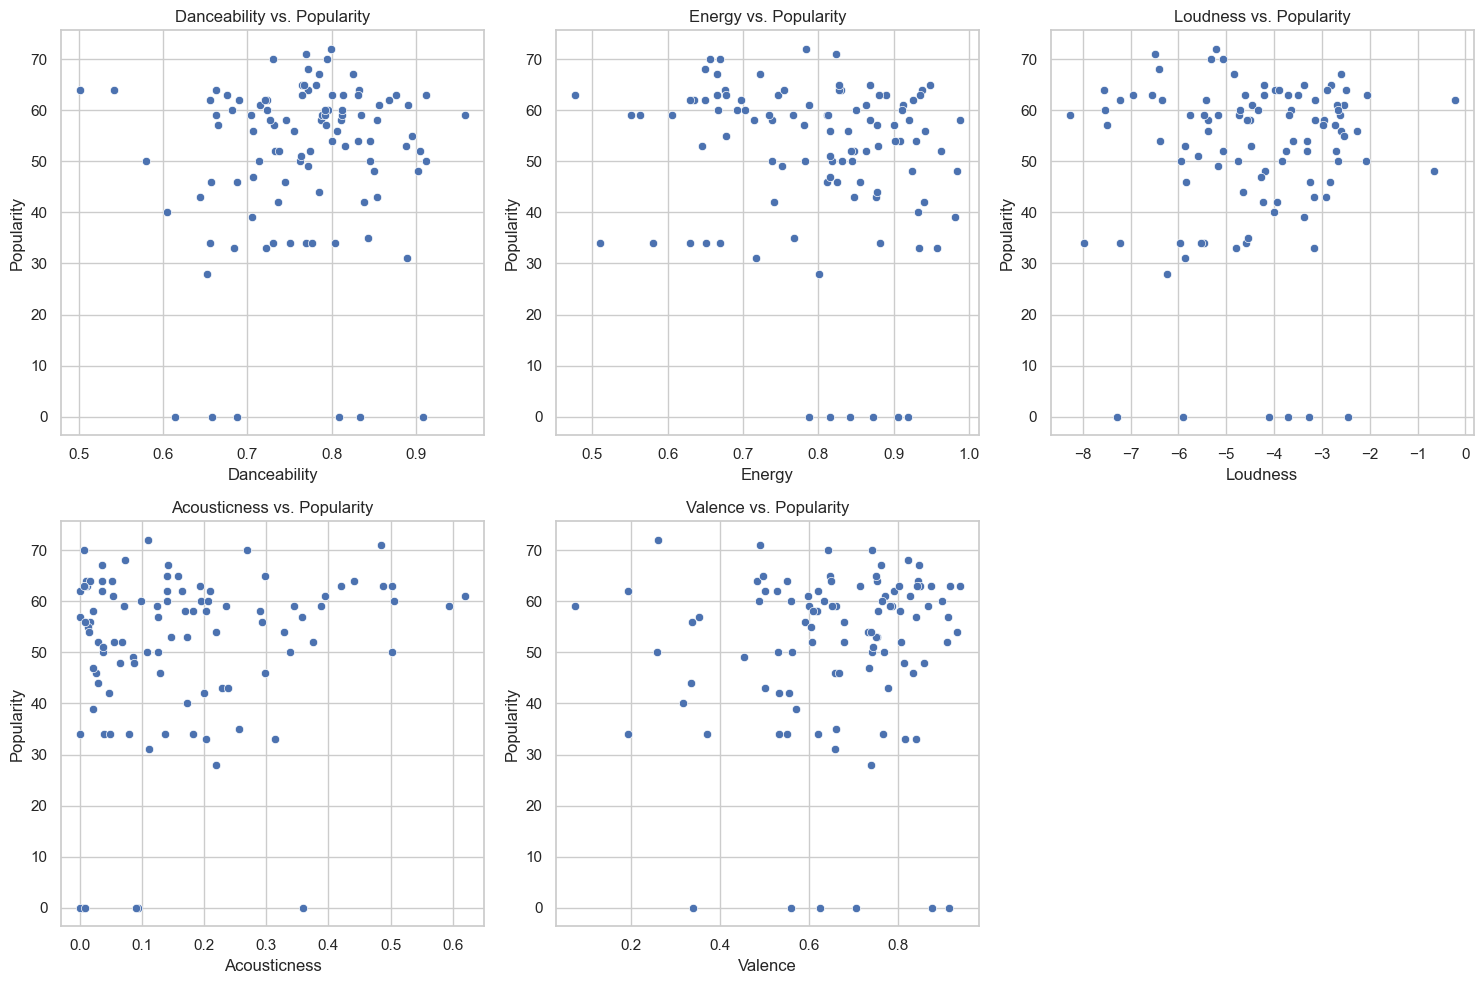

In [11]:
# creating scatter plots for various features vs. popularity
features = ['Danceability', 'Energy', 'Loudness', 'Acousticness', 'Valence']
plt.figure(figsize=(15, 10))

for i, feature in enumerate(features, 1):
    plt.subplot(2, 3, i)
    sns.scatterplot(x=music_data_cleaned[feature], y=music_data_cleaned['Popularity'])
    plt.title(f'{feature} vs. Popularity')
    plt.xlabel(feature)
    plt.ylabel('Popularity')

plt.tight_layout()
plt.show()

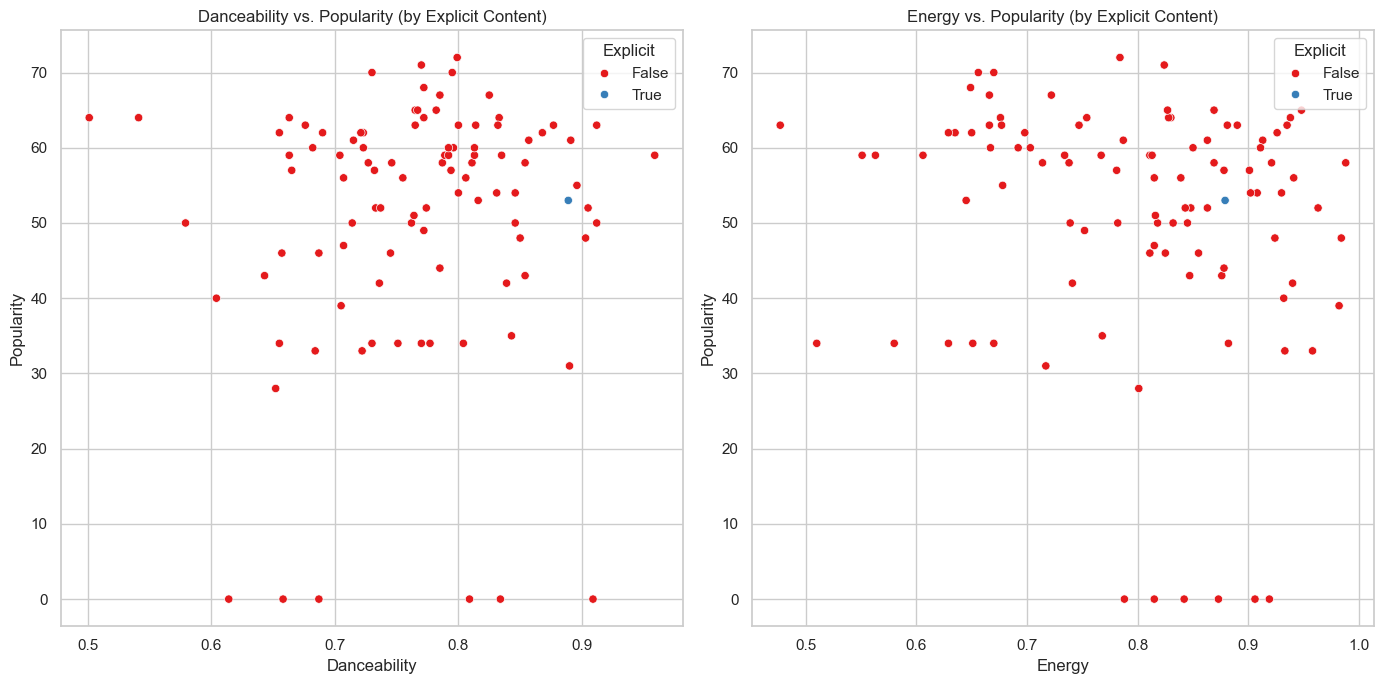

In [12]:
# creating plots for danceability vs. popularity and energy vs. popularity, segmented by explicit content
plt.figure(figsize=(14, 7))

# danceability vs. popularity
plt.subplot(1, 2, 1)
sns.scatterplot(x='Danceability', y='Popularity', hue='Explicit', data=music_data_cleaned, palette='Set1')
plt.title('Danceability vs. Popularity (by Explicit Content)')
plt.xlabel('Danceability')
plt.ylabel('Popularity')

# energy vs. popularity
plt.subplot(1, 2, 2)
sns.scatterplot(x='Energy', y='Popularity', hue='Explicit', data=music_data_cleaned, palette='Set1')
plt.title('Energy vs. Popularity (by Explicit Content)')
plt.xlabel('Energy')
plt.ylabel('Popularity')

plt.tight_layout()
plt.show()

## Modelling:

In [13]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.preprocessing import StandardScaler

# preparing the dataset for regression
# convert 'Explicit' from boolean to integer (0 or 1)
music_data_cleaned['Explicit'] = music_data_cleaned['Explicit'].astype(int)

# selecting features and target for the model
features = ['Danceability', 'Energy', 'Loudness', 'Acousticness', 'Valence', 'Explicit', 'Key', 'Mode', 'Speechiness', 'Instrumentalness', 'Tempo']
X = music_data_cleaned[features]
y = music_data_cleaned['Popularity']

# standardizing the features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# splitting the dataset into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)

# initializing and training the linear regression model
model = LinearRegression()
model.fit(X_train, y_train)

# predicting on the test set
y_pred = model.predict(X_test)

# evaluating the model
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

# outputting the coefficients and performance metrics
coefficients = pd.Series(model.coef_, index=features)
coefficients

Danceability        1.249640e+00
Energy             -3.204815e+00
Loudness            1.141456e+00
Acousticness        2.469403e+00
Valence             2.125671e+00
Explicit           -3.108624e-14
Key                -3.189486e+00
Mode               -5.859715e+00
Speechiness         3.398224e-02
Instrumentalness    3.390750e-01
Tempo              -1.865736e+00
dtype: float64